# SMPS Output Filter Design

## Overview

This notebook records the design of the output filter for the DCDC block based on the app note (Input Filter Design for Switching Power Supplies)[https://www.ti.com/lit/an/snva538/snva538.pdf].

In [60]:
#
# ESR Calc
#

import numpy as np

tan_d = 0.14
C = 220e-6
f_meas = 5000
ESR = tan_d/(2 * np.pi * f_meas * C)

print(f"ESR = {ESR:.4f} Ohms at {f_meas} Hz")


ESR = 0.0203 Ohms at 5000 Hz


Ideal Rd for zeta=1/sqrt(2): 0.4708 Ohms
Natural frequency (fo): 7341.27 Hz
Zeta: 0.5766, Rd: 0.50 Ohms, f_max: 4786.30 Hz, H_max: 3.2748dB, H_sw: -62.2964dB, I_ripple_max: 0.3228 A


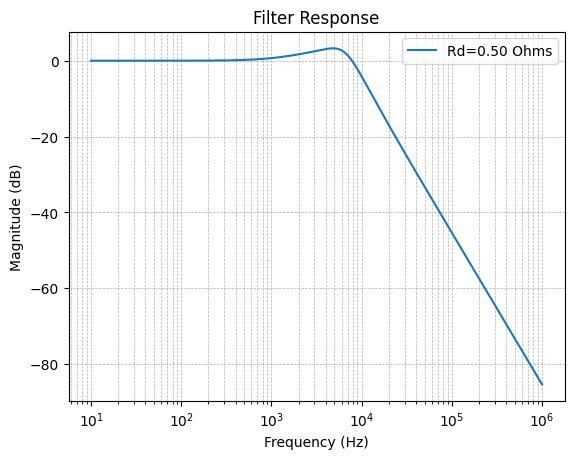

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

L = 10e-6
C = 47e-6
n = 4
Rd = .15
Cd = 220e-6 #n*C

#
# REC30K
#
f_sw = 265e3    # REC30K switching frequency
V_OUT = 12      # positive rail
V_IN = 15       # max input voltage
deltaV = 0.08   # typical ripple voltage (0.08V for REC30K)

f = np.logspace(1, 6, 501)
w = 2 * np.pi * f
s = 1j * w

def H_filter_func(s, L, C, Rd, Cd):
    Z1 = s * L
    Z2 = 1. / (s * C)
    Z3 = Rd + 1. / (s * Cd)

    Z2llZ3 = 1. / (1. / Z2 + 1. / Z3)

    H = Z2llZ3 / (Z1 + Z2llZ3)
    Z = Z1 + Z2llZ3
    return H, Z

zeta_ideal = np.sqrt((2+n)*(4+3*n)/2/n**2/(4+n))
Rd_ideal = (n + 1)/n * 1/(2*zeta_ideal) * np.sqrt(L / C)
print(f"Ideal Rd for zeta=1/sqrt(2): {Rd_ideal:.4f} Ohms")

wo = 1 / np.sqrt(L * C)
fo = wo / (2 * np.pi)
print(f"Natural frequency (fo): {fo:.2f} Hz")

Rd_values = np.linspace(0.15, 0.75, 13)
#Rd_values = [0.5]

for Rd in Rd_values:
    H_filter, Z_filter = H_filter_func(s, L, C, Rd, Cd)

    zeta = (n + 1)/n * 1/(2*Rd) * np.sqrt(L / C) 

    H_max = np.max(np.abs(H_filter))
    f_max = f[np.argmax(np.abs(H_filter))]
    I_ripple = deltaV / Z_filter
    I_ripple_max = np.max(np.abs(I_ripple))

    # get the magnitude of the filter transfer functoin at the switching frequency f_sw
    H_sw, _ = H_filter_func(1j * 2 * np.pi * f_sw, L, C, Rd, Cd)
    H_sw_mag = np.abs(H_sw)

    print(f"Zeta: {zeta:.4f}, Rd: {Rd:.2f} Ohms, f_max: {f_max:.2f} Hz, H_max: {20*np.log10(np.abs(H_max)):.4f}dB, H_sw: {20*np.log10(np.abs(H_sw_mag)):.4f}dB, I_ripple_max: {I_ripple_max:.4f} A")
    
    plt.semilogx(f, 20 * np.log10(np.abs(H_filter)))

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title("Filter Response")
plt.legend([f"Rd={Rd:.2f} Ohms" for Rd in Rd_values], loc='best')
plt.show()